<a href="https://colab.research.google.com/github/KavyaSP2808/AIML-/blob/project/Fundamentals%20of%20Neural%20Networks/CNNs/Intro%20to%20CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks (CNNs)

## Introduction
A Convolutional Neural Network (CNN) is a type of deep learning model primarily used for image processing, computer vision, and other grid-like data tasks. CNNs automatically and adaptively learn spatial hierarchies of features through convolution operations, making them highly effective for tasks like image classification, object detection, and segmentation.

## Key Components of CNNs

### 1. Convolutional Layer (Filters/Kernels)

*  Purpose: Automatically extract features from input data (e.g., edges, textures, shapes in images).
*  Operation: A small matrix called a filter (or kernel) slides over the input image to compute feature maps via element-wise multiplication and summation.
*  Mathematical Representation:
[ S(i,j) = (X * K)(i,j) = \sum_m \sum_n X(i+m, j+n) \cdot K(m,n) ]

Where:

    *   (X) = input image
    *   (K) = filter/kernel
    *   (S) = resulting feature map
    *   Filters learn important patterns during training. Multiple filters capture multiple types of features.


### 2. Activation Functions

*  Introduce non-linearity to allow the network to learn complex patterns.
*  Common activations in CNNs:
    *  ReLU (Rectified Linear Unit): (f(x) = \max(0, x))
    *  Leaky ReLU: Prevents dead neurons.


### 3. Pooling Layer

*  Purpose: Reduce spatial dimensions of feature maps, lowering computation and controlling overfitting.
*  Types:
    *  Max Pooling: Takes the maximum value in a window.
    *  Average Pooling: Takes the average value in a window
*  Example: A 2x2 max pooling reduces a 4x4 feature map to 2x2.

### 4.Fully Connected Layer
*  After convolution and pooling, feature maps are flattened into a 1D vector.
*  Fully connected layers perform high-level reasoning and map features to final outputs (e.g., class scores).

### 5.Droupout Layer
*  Randomly ignores neurons during training to prevent overfitting and improve generalization.


### 6.Applications of CNNs


*  Image Classification (e.g., MNIST, CIFAR-10)
*  Object Detection (e.g., YOLO, Faster R-CNN)
*  Image Segmentation (e.g., U-Net)
*  Facial Recognition
*  Video Analysis
*  Medical Imaging (e.g., tumor detection)






11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8672 - loss: 0.4399 - val_accuracy: 0.9778 - val_loss: 0.0705
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.9837 - loss: 0.0543 - val_accuracy: 0.9857 - val_loss: 0.0490
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9887 - loss: 0.0356 - val_accuracy: 0.9857 - val_loss: 0.0484
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9924 - loss: 0.0237 - val_accuracy: 0.9894 - val_loss: 0.0363
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9929 - loss: 0.0208 - val_accuracy: 0.9858 - val_loss: 0.0492
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.9950 - loss: 0.0156 - val_accuracy: 0.9900 - val_loss: 0.0365
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9962 - loss: 0.0115 - val_accuracy: 0.9900 - val_loss: 0.0452
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9968 - loss: 0.0088 - 

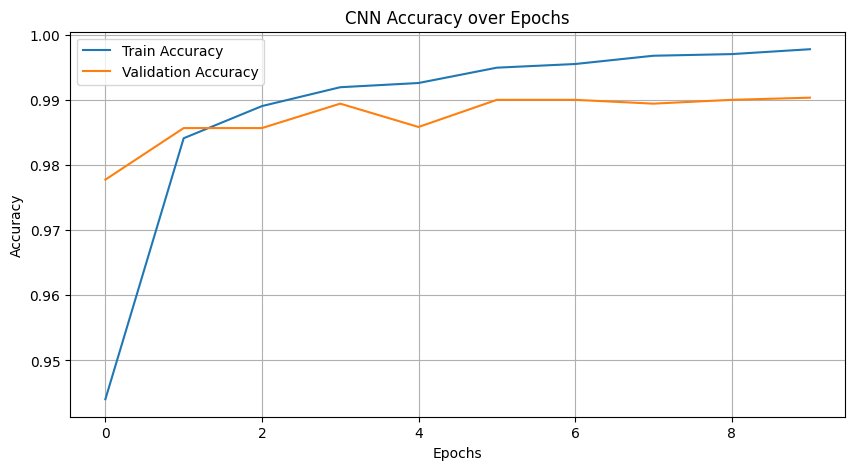

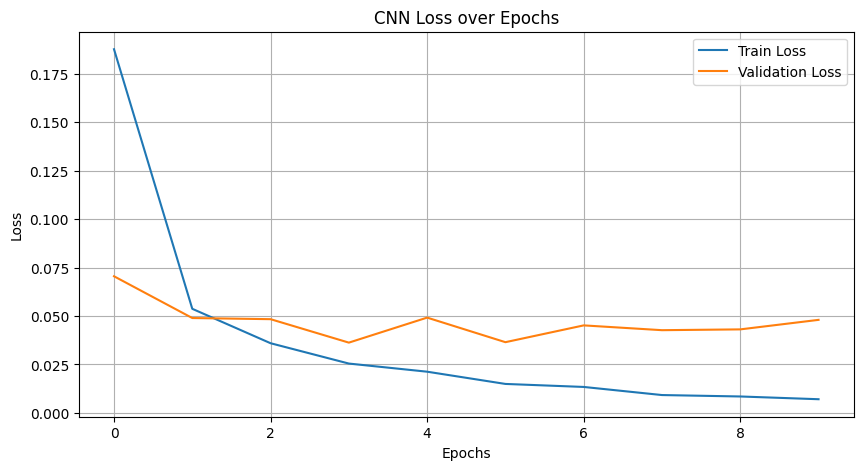

In [ ]:
# ==============================
# Convolutional Neural Network (CNN) Example with TensorFlow/Keras
# ==============================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Load dataset (MNIST)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Preprocess data
# Reshape to add channel dimension and normalize
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Build CNN model
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# 4. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

# 6. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 7. Plot training history
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()